# Notebook 01 — Data Exploration

**Goal:** Understand the structure, quality, and characteristics of the Backblaze Hard Drive Stats dataset before we build any ML models.

**Dataset:** Backblaze publishes daily snapshots of every hard drive in their data centers. Each row is one drive on one day, with S.M.A.R.T. sensor readings and a `failure` flag (1 = drive failed that day, 0 = still healthy).

---

## Step 1 — Import Libraries

**What are libraries?**  
Think of Python like a basic kitchen — it comes with a stove and a sink, enough to do the basics. But to cook a serious meal, you need specialized tools: a blender, a thermometer, a food processor. **Libraries are those specialized tools.** They are collections of pre-written, tested code that we bring into our project with the `import` keyword.

**Why these four libraries?**

| Library | Purpose | Why We Need It |
|---|---|---|
| `pandas` | Data manipulation in table format (rows & columns) | Our CSV is a table — pandas lets us load, filter, and summarize it |
| `numpy` | Fast math on arrays of numbers | Many pandas operations depend on numpy under the hood; we'll also use it for numerical checks |
| `matplotlib` | Creates static charts and plots | We need to visualize distributions and comparisons |
| `seaborn` | Statistical visualizations (built on top of matplotlib) | Gives us prettier, more informative charts with less code |

In [ ]:
# ============================================================
# Step 1 — Import Libraries
# ============================================================

import pandas as pd      # "pd" is the universal shorthand — every tutorial and doc uses it
import numpy as np       # "np" is numpy's standard alias
import matplotlib.pyplot as plt   # pyplot is matplotlib's plotting interface; "plt" is the convention
import seaborn as sns    # "sns" is seaborn's standard alias (named after a character in The West Wing)

# Tell matplotlib to render plots directly inside the notebook
%matplotlib inline

# Optional: set a clean visual style for all our plots
sns.set_style('whitegrid')          # white background with subtle gridlines
plt.rcParams['figure.figsize'] = (10, 6)   # default figure size: 10 inches wide, 6 inches tall
plt.rcParams['figure.dpi'] = 100           # resolution — 100 dots per inch

print('All libraries imported successfully!')

### What just happened?

If you see **"All libraries imported successfully!"** above, it means:

1. **`pandas`** is ready — we can now load CSV files into DataFrames (more on that in Step 2)
2. **`numpy`** is ready — fast numerical operations are available
3. **`matplotlib`** is ready — we can create charts
4. **`seaborn`** is ready — we can create prettier statistical charts

**Why the aliases (`pd`, `np`, `plt`, `sns`)?**  
These are universal conventions. Every data science tutorial, Stack Overflow answer, and official doc uses these same short names. Using them means: (a) less typing, and (b) anyone reading your code instantly knows what library you're using.

**What is `%matplotlib inline`?**  
This is a Jupyter "magic command" (starts with `%`). It tells the notebook to display plots *directly below the code cell* instead of opening a separate window. Without it, your charts would pop up in a new window every time.

**What did `sns.set_style` and `plt.rcParams` do?**  
These set the *default look* for every chart we create in this notebook — white background, gridlines, a reasonable size (10×6 inches), and good resolution (100 DPI). This saves us from repeating styling code for every single plot.

---

✅ **Step 1 complete.** Next up: **Step 2 — Loading the CSV file into a Pandas DataFrame.**

## Step 2 — Load the CSV File into a DataFrame

**What is a DataFrame?**

Imagine a **spreadsheet** — like an Excel sheet or a Google Sheet. It has rows, columns, headers at the top, and each cell holds a value. A **DataFrame** is exactly that, but *inside Python's memory*. It is pandas' core data structure.

Key properties of a DataFrame:
- **Each row** = one observation (in our case, one hard drive on one day)
- **Each column** = one feature/measurement (temperature, serial number, failure status, etc.)
- **Every column has a name** (the header from the CSV)
- **Every row has an index** (a row number, starting from 0 by default)

**What does `pd.read_csv()` do?**

It opens the CSV file on disk, reads it line by line, splits each line at the commas, and constructs a DataFrame in memory. Think of it as: *"Open this file, parse the commas, and build me a nice table I can work with programmatically."*

**Why just one day's file?**

We have 92 daily CSV files (Oct 1 – Dec 31, 2025). For exploration, we only need *one day* to understand the structure — column names, data types, missing values, etc. These stay consistent across days. Loading all 92 files at once would be slow and unnecessary right now.

In [ ]:
# ============================================================
# Step 2 — Load One Day of Data
# ============================================================

# Define the path to our CSV file
# We pick the first day in the dataset: October 1, 2025
csv_path = '../data/raw/data_Q4_2025/2025-10-01.csv'

# Read the CSV file into a DataFrame
# pd.read_csv() does all the heavy lifting:
#   - Opens the file
#   - Reads the first line as column headers
#   - Parses every subsequent line as a row of data
#   - Infers the data type of each column (number, text, etc.)
df = pd.read_csv(csv_path)

# Confirm it loaded — print the type and a quick summary
print(f'Type of df: {type(df)}')
print(f'Successfully loaded: {csv_path}')

### What just happened?

1. **`csv_path = '../data/raw/data_Q4_2025/2025-10-01.csv'`** — We stored the file path in a variable. The `..` means "go up one folder" (from `notebooks/` back to the project root, then into `data/raw/...`). Using a variable makes it easy to swap files later.

2. **`df = pd.read_csv(csv_path)`** — This is the big one. pandas opened the file, parsed all the commas, figured out column types, and built a full DataFrame in memory. We stored it in a variable called `df` (short for DataFrame — another universal convention).

3. **`type(df)`** confirms the object is a `pandas.core.frame.DataFrame` — meaning pandas successfully built the table structure.

At this point, all the data is sitting in memory inside `df`. We haven't looked at it yet — that's what the next steps are for.

---

✅ **Step 2 complete.** Next up: **Step 3 — Checking the shape of the data (rows × columns).**

## Step 3 — Check the Shape of the Data

**What does "shape" mean?**

Think of your DataFrame as a big grid. The **shape** tells you its dimensions — like measuring a wall before you paint it. You need to know how big it is before you start working on it.

- **Rows** = how many hard drives were reporting data on that day (each row is one drive)
- **Columns** = how many pieces of information we have about each drive (each column is one measurement)

**Why check shape first?**

1. **Sanity check** — did the file load correctly? If you expected ~300K drives but got 5 rows, something went wrong.
2. **Scale awareness** — knowing you have 300K+ rows tells you this is a substantial dataset, enough for ML to learn patterns.
3. **Feature count** — knowing the column count tells you how many potential inputs your model could use.

**Syntax note:** `df.shape` has no parentheses because `.shape` is a **property** (a stored fact), not a **method** (an action). Think of it like checking a book's page count — the book already knows; you're just reading it off the cover.

In [ ]:
# ============================================================
# Step 3 — Check the Shape of the Data
# ============================================================

# df.shape returns a tuple: (number_of_rows, number_of_columns)
print(f'Shape of the DataFrame: {df.shape}')
print()

# Let's unpack it into separate variables for clarity
rows, cols = df.shape
print(f'Number of rows (drives reporting that day): {rows:,}')
print(f'Number of columns (features per drive):    {cols}')

### What does this output tell us?

You should see something like:
```
Shape of the DataFrame: (330866, 197)

Number of rows (drives reporting that day): 330,866
Number of columns (features per drive):    197
```

**Breaking this down:**

- **330,866 rows** — On October 1, 2025, Backblaze had roughly 330K hard drives spinning in their data centers. Every single one reported its health data that day, and each one became a row in this file. That's a *lot* of drives — great for ML because more data generally means the model can learn more reliable patterns.

- **197 columns** — Each drive reported 197 pieces of information. But not all of these are useful. They include:
  - **Metadata columns** (~10): `date`, `serial_number`, `model`, `capacity_bytes`, `failure`, `datacenter`, `cluster_id`, `vault_id`, `pod_id`, `pod_slot_num`, `is_legacy_format`
  - **S.M.A.R.T. attribute columns** (~186): Each S.M.A.R.T. attribute comes in *two* flavors — `smart_X_normalized` and `smart_X_raw` — which is why there are so many columns. We'll explore what these mean in Step 5.

**What is a tuple?**

`df.shape` returns a **tuple** — think of it as an immutable (unchangeable) pair of values wrapped in parentheses: `(rows, cols)`. The line `rows, cols = df.shape` is called **unpacking** — it splits the tuple into two separate variables so we can use them individually.

**What does `{rows:,}` mean?**

The `:,` inside the f-string is a formatting trick — it adds commas as thousand separators. So `330866` becomes `330,866`, which is much easier to read at a glance.

---

✅ **Step 3 complete.** Next up: **Step 4 — Looking at the first few rows to understand the structure.**

## Step 4 — Look at the First Few Rows

**Why do we need to see the actual data?**

Step 3 told us the *dimensions* of our table (330K × 197), but not what's actually *inside* the cells. Looking at real rows is like opening a book and reading the first page — you instantly get a feel for the content.

Specifically, we want to answer:
- What kind of values are in each column? (numbers? text? dates?)
- Do any values look weird or unexpected?
- Are there empty cells? (shown as `NaN` — "Not a Number")

**The problem:** With 197 columns, `df.head()` will truncate and show "..." in the middle, hiding most columns. So we'll use a **two-step approach**:
1. First, look at the **metadata columns** (the identifiers and labels — the first 11 columns)
2. Then, look at a **sample of S.M.A.R.T. columns** (the actual sensor readings)

**What is `df.head()`?**

It returns the **first 5 rows** of the DataFrame by default. You can pass a number to change how many rows: `df.head(3)` shows 3 rows, `df.head(10)` shows 10. This is useful because printing all 330K rows would flood your screen and crash the notebook.

In [4]:
# ============================================================
# Step 4a — Look at the Metadata Columns (first 11)
# ============================================================

# The metadata columns are the first 11 columns in the dataset.
# These identify each drive — they are NOT sensor readings.
#
# We use df.head() to get the first 5 rows,
# then .iloc[:, :11] to select only the first 11 columns.
#
# .iloc stands for "integer location" — it selects by position:
#   - [:] means "all rows" (but head() already limited us to 5)
#   - [:11] means "columns at positions 0 through 10"

print('=== Metadata Columns (first 11) ===')
print()
df.head().iloc[:, :11]

=== Metadata Columns (first 11) ===



,date,serial_number,model,capacity_bytes,failure,datacenter,cluster_id,vault_id,pod_id,pod_slot_num,is_legacy_format
0,2025-10-01,2206E608DB42,CT250MX500SSD1,250059350016,0,sac0,0,1028,4,NaN,False
1,2025-10-01,2207E60CC65A,CT250MX500SSD1,250059350016,0,sac0,0,1028,13,NaN,False
2,2025-10-01,2340E87B92B5,CT250MX500SSD1,250059350016,0,sac0,0,1028,14,NaN,False
3,2025-10-01,2340E87B97E8,CT250MX500SSD1,250059350016,0,sac0,0,1028,2,NaN,False
4,2025-10-01,2407E896B6D5,CT250MX500SSD1,250059350016,0,sac0,0,1028,8,NaN,False


In [5]:
# ============================================================
# Step 4b — Look at a Sample of S.M.A.R.T. Columns
# ============================================================

# The S.M.A.R.T. columns start at position 11.
# Let's pick a handful of the most commonly useful ones
# to see what actual drive health data looks like.
#
# We'll select specific columns by name using double brackets [[ ]]
# (single brackets select one column, double brackets select multiple)

smart_sample_cols = [
    'smart_1_raw',     # Read Error Rate
    'smart_5_raw',     # Reallocated Sectors Count
    'smart_9_raw',     # Power-On Hours
    'smart_194_raw',   # Temperature (Celsius)
    'smart_197_raw',   # Current Pending Sector Count
    'smart_198_raw',   # Uncorrectable Sector Count
]

print('=== Sample S.M.A.R.T. Columns (raw values) ===')
print()
df[smart_sample_cols].head(10)

=== Sample S.M.A.R.T. Columns (raw values) ===



,smart_1_raw,smart_5_raw,smart_9_raw,smart_194_raw,smart_197_raw,smart_198_raw
0,0.0,0.0,314.0,35.0,0.0,0.0
1,0.0,0.0,23375.0,37.0,0.0,0.0
2,0.0,0.0,9923.0,36.0,0.0,0.0
3,0.0,0.0,5041.0,37.0,0.0,0.0
4,0.0,0.0,1196.0,28.0,0.0,0.0
5,0.0,0.0,39090.0,28.0,0.0,0.0
6,0.0,0.0,77683.0,34.0,0.0,0.0
7,0.0,0.0,77738.0,32.0,0.0,0.0
8,0.0,NaN,49093.0,39.0,NaN,NaN
9,2816.0,0.0,78798.0,40.0,0.0,0.0


### What does this output tell us?

**Step 4a — The Metadata Columns:**

| Column | Example Value | What It Means |
|---|---|---|
| `date` | `2025-10-01` | The day this snapshot was taken |
| `serial_number` | `2206E608DB42` | Unique ID for this specific physical drive |
| `model` | `CT250MX500SSD1` | The make/model of the drive |
| `capacity_bytes` | `250059350016` | Drive size in bytes (~250 GB) |
| `failure` | `0` | **Our target variable!** 0 = healthy, 1 = failed that day |
| `datacenter` | `sac0` | Which Backblaze datacenter the drive is in |
| `cluster_id` | `0` | Cluster within the datacenter |
| `vault_id` | `1028` | Storage vault within the cluster |
| `pod_id` | `4` | Physical pod/server the drive sits in |
| `pod_slot_num` | `NaN` | Slot position (often missing — that's okay) |
| `is_legacy_format` | `False` | Whether this row uses an older data format |

Notice that `failure` is **0 for every row shown** — which makes sense because drive failures are extremely rare events. This tells us we likely have an **imbalanced dataset** (way more 0s than 1s), which will be important when building our ML model.

**Step 4b — The S.M.A.R.T. Columns:**

You should see numerical values and some `NaN` entries. Key observations:
- **`smart_9_raw`** (Power-On Hours) — shows how long each drive has been running. Numbers in the thousands mean the drive has been on for months or years.
- **`smart_194_raw`** (Temperature) — should show reasonable temperatures (20–50°C range).
- **`smart_5_raw`** (Reallocated Sectors) — healthy drives show `0`. A non-zero value means the drive has started remapping bad sectors — an early warning sign.
- **`NaN` values** — some drives don't report all S.M.A.R.T. attributes. This is normal — different drive models support different sensors. We'll deal with this in Step 6.

**New syntax concepts:**
- **`.iloc[:, :11]`** — selects by integer position. `:` = all rows, `:11` = first 11 columns
- **`df[['col1', 'col2']]`** — selects specific columns by name. Double brackets return a DataFrame (not just a single column)

---

✅ **Step 4 complete.** Next up: **Step 5 — Checking all column names and understanding what the important ones mean.**

## Step 5 — Check All Column Names & Understand the Important Ones

**What are we doing and why?**

We have 197 columns, but we don't need all of them. In fact, most S.M.A.R.T. attributes are barely populated — many drives don't report them. Before building any ML model, we need to know:

1. **What columns exist** — the full inventory
2. **What each important one measures** — so we know what we're feeding into a model
3. **Which ones are usable** — if a column is 99% empty, it's useless for prediction

**What is S.M.A.R.T.?**

S.M.A.R.T. stands for **Self-Monitoring, Analysis and Reporting Technology**. It's a built-in monitoring system inside every modern hard drive and SSD. Think of it like a car's dashboard — it tracks internal health metrics like temperature, error counts, and hours of use. Each metric has a number (e.g., SMART 9 = Power-On Hours).

**Normalized vs. Raw — why two columns per attribute?**

Each S.M.A.R.T. attribute appears twice:
- **`smart_X_raw`** — the actual measured value (e.g., temperature = 35°C, power-on hours = 23,375)
- **`smart_X_normalized`** — the manufacturer's "health score" scaled to 0–100 or 0–253. Higher = healthier.

We'll mostly use **raw** values because they're more interpretable and consistent across manufacturers.

In [10]:
# ============================================================
# Step 5a — List All Column Names
# ============================================================

# df.columns gives us an Index object with all column names
# .tolist() converts it to a plain Python list for easier reading
all_columns = df.columns.tolist()

# Separate metadata columns from SMART columns
metadata_cols = [c for c in all_columns if not c.startswith('smart_')]
smart_cols = [c for c in all_columns if c.startswith('smart_')]

print(f'Total columns: {len(all_columns)}')
print(f'Metadata columns: {len(metadata_cols)}')
print(f'S.M.A.R.T. columns: {len(smart_cols)}')
print()
print('=== Metadata Columns ===')
print(metadata_cols)
print()

# Extract unique SMART attribute numbers
# e.g., from 'smart_194_raw' we extract 194
import re
smart_numbers = sorted(set(
    int(re.search(r'smart_(\d+)_', col).group(1))
    for col in smart_cols
))
print(f'Unique S.M.A.R.T. attributes tracked: {len(smart_numbers)}')
print(f'Attribute numbers: {smart_numbers}')

Total columns: 197
Metadata columns: 11
S.M.A.R.T. columns: 186

=== Metadata Columns ===
['date', 'serial_number', 'model', 'capacity_bytes', 'failure', 'datacenter', 'cluster_id', 'vault_id', 'pod_id', 'pod_slot_num', 'is_legacy_format']

Unique S.M.A.R.T. attributes tracked: 93
Attribute numbers: [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 22, 23, 24, 27, 71, 82, 90, 160, 161, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 206, 210, 211, 212, 218, 220, 222, 223, 224, 225, 226, 230, 231, 232, 233, 234, 235, 240, 241, 242, 244, 245, 246, 247, 248, 250, 251, 252, 254, 255]


In [7]:
# ============================================================
# Step 5b — Check Which SMART Attributes Are Actually Populated
# ============================================================

# Not all drives report all SMART attributes.
# Let's check what percentage of rows have non-null values
# for each SMART raw attribute.
#
# .notna() returns True/False for each cell (True = has a value)
# .mean() calculates the fraction of True values (0.0 to 1.0)
# Multiply by 100 to get a percentage.

smart_raw_cols = [c for c in all_columns if c.endswith('_raw')]

coverage = pd.DataFrame({
    'column': smart_raw_cols,
    'populated_pct': [df[c].notna().mean() * 100 for c in smart_raw_cols]
})

# Sort by coverage so the most-populated appear first
coverage = coverage.sort_values('populated_pct', ascending=False).reset_index(drop=True)

print('=== S.M.A.R.T. Attribute Coverage (% of rows with data) ===')
print()
print(coverage.to_string(index=False))

=== S.M.A.R.T. Attribute Coverage (% of rows with data) ===

       column  populated_pct
  smart_9_raw      99.870038
 smart_12_raw      99.870038
smart_194_raw      99.868225
  smart_1_raw      99.774229
smart_192_raw      99.529719
  smart_5_raw      99.315433
smart_199_raw      99.315433
smart_198_raw      99.219624
  smart_3_raw      98.975114
  smart_7_raw      98.975114
  smart_4_raw      98.975114
smart_193_raw      98.954259
 smart_10_raw      98.249745
smart_197_raw      97.420104
smart_240_raw      65.436461
smart_196_raw      64.619211
  smart_2_raw      64.373493
  smart_8_raw      64.373493
smart_241_raw      44.342725
smart_242_raw      44.340911
smart_191_raw      38.697237
smart_187_raw      34.160959
smart_188_raw      33.997147
smart_190_raw      33.849655
 smart_24_raw      33.269964
 smart_23_raw      33.269964
 smart_22_raw      31.655413
smart_226_raw      31.584085
smart_220_raw      31.584085
smart_222_raw      31.584085
smart_223_raw      27.116113
smart_200_r

In [8]:
# ============================================================
# Step 5c — Focus on Well-Populated Attributes (>90% coverage)
# ============================================================

# For ML, we need columns that have data for most rows.
# Let's filter to attributes with >90% coverage.

well_populated = coverage[coverage['populated_pct'] > 90.0]

print(f'Attributes with >90% coverage: {len(well_populated)} out of {len(coverage)}')
print()
print(well_populated.to_string(index=False))

Attributes with >90% coverage: 14 out of 93

       column  populated_pct
  smart_9_raw      99.870038
 smart_12_raw      99.870038
smart_194_raw      99.868225
  smart_1_raw      99.774229
smart_192_raw      99.529719
  smart_5_raw      99.315433
smart_199_raw      99.315433
smart_198_raw      99.219624
  smart_3_raw      98.975114
  smart_7_raw      98.975114
  smart_4_raw      98.975114
smart_193_raw      98.954259
 smart_10_raw      98.249745
smart_197_raw      97.420104


### What does this output tell us?

**Step 5a — Column Inventory:**
- 11 metadata columns (identifiers, not sensor data)
- 186 S.M.A.R.T. columns (93 attributes × 2 versions: normalized + raw)
- 93 unique S.M.A.R.T. attribute numbers are tracked

**Step 5b — Coverage Reality Check:**

This is a critical finding. Of the 93 S.M.A.R.T. attributes:
- **~14 have >90% coverage** — these are widely reported across almost all drives
- **~30 have <1% coverage** — these are nearly empty and useless for ML
- The rest fall in between

This happens because different drive manufacturers and models support different S.M.A.R.T. attributes. An SSD might not report the same metrics as a traditional spinning hard drive.

**Step 5c — The Well-Populated Attributes (our most useful features):**

Here's what the key ones with >90% coverage actually measure:

| Attribute | Name | What It Measures | Why It Matters for Failures |
|---|---|---|---|
| `smart_1_raw` | Read Error Rate | Number of read errors | Increasing errors can signal surface degradation |
| `smart_3_raw` | Spin-Up Time | Time to spin the platters to full speed (ms) | Slowing spin-up suggests motor issues |
| `smart_4_raw` | Start/Stop Count | How many times the drive has powered on/off | High cycling causes wear |
| `smart_5_raw` | Reallocated Sector Count | Bad sectors remapped to spare area | **Strong failure predictor** — drives run out of spares |
| `smart_7_raw` | Seek Error Rate | Errors when the read/write head moves | Head positioning problems |
| `smart_9_raw` | Power-On Hours | Total hours the drive has been running | Older drives fail more (wear-out) |
| `smart_10_raw` | Spin Retry Count | Times the drive retried spinning up | Motor struggling |
| `smart_12_raw` | Power Cycle Count | Number of full power on/off cycles | Similar to Start/Stop Count |
| `smart_192_raw` | Power-Off Retract Count | Emergency head park events | Sudden power losses stress the drive |
| `smart_193_raw` | Load/Unload Cycle Count | Head load/unload events | Mechanical wear indicator |
| `smart_194_raw` | Temperature (°C) | Current drive temperature | Overheating accelerates failure |
| `smart_197_raw` | Current Pending Sectors | Sectors waiting to be remapped | **Strong failure predictor** — imminent bad sectors |
| `smart_198_raw` | Uncorrectable Sector Count | Sectors that couldn't be recovered | Data loss has already occurred |
| `smart_199_raw` | UltraDMA CRC Error Count | Data transfer errors between drive and motherboard | Cable or interface issues |

**Key takeaway for our project:** We won't need all 93 S.M.A.R.T. attributes. In the data cleaning notebook we'll select the ~14 well-populated ones, which are also the most established predictors of drive failure in published research.

---

✅ **Step 5 complete.** Next up: **Step 6 — Checking for missing values and understanding why they matter in ML.**

## Step 6 — Check for Missing Values

**What are missing values?**

In a DataFrame, a missing value is shown as **`NaN`** (Not a Number). It means "this cell has no data." Think of it like a blank cell in a spreadsheet — you can see the cell exists, but nobody filled it in.

**Why do missing values matter in ML?**

Most machine learning algorithms **cannot handle blank cells**. They expect a number in every position. If you feed a model a row with NaN values, it will either crash or produce garbage results. So we need to know:

1. **How many** values are missing? (Is it a small or big problem?)
2. **Where** are they missing? (Which columns are affected?)
3. **Why** are they missing? (Random gaps, or a structural reason?)

Once we know this, we can decide how to **handle** them in the data cleaning notebook:
- **Fill them** with a default value (like 0 or the column's average) — called *imputation*
- **Drop the column** entirely if it's mostly empty
- **Drop the row** if only a few rows are affected

In [11]:
# ============================================================
# Step 6a — Overall Missing Value Summary
# ============================================================

# Calculate the total number of missing values across the entire DataFrame
# .isna() marks every cell as True (missing) or False (has data)
# .sum() adds up the True values (True = 1, False = 0)
# Calling .sum() twice: first sums per column, then sums across all columns

total_cells = df.shape[0] * df.shape[1]   # rows x columns = total cells
total_missing = df.isna().sum().sum()       # total NaN count

print(f'Total cells in DataFrame:  {total_cells:,}')
print(f'Total missing values:      {total_missing:,}')
print(f'Percentage missing:        {total_missing / total_cells * 100:.1f}%')

Total cells in DataFrame:  65,180,602
Total missing values:      46,689,554
Percentage missing:        71.6%


In [12]:
# ============================================================
# Step 6b — Missing Values Per Column (Top 20 + Bottom 10)
# ============================================================

# Count missing values per column and sort (most missing first)
# .isna().sum() gives one number per column: how many NaNs it has

missing_per_col = df.isna().sum().sort_values(ascending=False)

# Build a summary DataFrame for readability
missing_summary = pd.DataFrame({
    'missing_count': missing_per_col,
    'missing_pct': (missing_per_col / len(df) * 100).round(1)
})

print('=== TOP 20 Columns with Most Missing Values ===')
print(missing_summary.head(20).to_string())
print()

# Columns with ZERO missing values
zero_missing = missing_summary[missing_summary['missing_count'] == 0]
print(f'=== Columns with ZERO Missing Values ({len(zero_missing)}) ===')
print(zero_missing.index.tolist())

=== TOP 20 Columns with Most Missing Values ===
                      missing_count  missing_pct
smart_164_raw                330866        100.0
smart_160_normalized         330866        100.0
smart_160_raw                330866        100.0
smart_15_raw                 330866        100.0
smart_15_normalized          330866        100.0
smart_161_raw                330866        100.0
smart_161_normalized         330866        100.0
smart_163_raw                330866        100.0
smart_163_normalized         330866        100.0
smart_164_normalized         330866        100.0
smart_176_normalized         330866        100.0
smart_251_raw                330866        100.0
smart_251_normalized         330866        100.0
smart_255_raw                330866        100.0
smart_255_normalized         330866        100.0
smart_250_normalized         330866        100.0
smart_250_raw                330866        100.0
smart_176_raw                330866        100.0
smart_178_raw        

In [13]:
# ============================================================
# Step 6c — Missing Values in Our Key SMART Attributes
# ============================================================

# These are the ~14 well-populated attributes we identified in Step 5.
# Let's see exactly how many missing values each one has.

key_smart_cols = [
    'smart_1_raw',     # Read Error Rate
    'smart_3_raw',     # Spin-Up Time
    'smart_4_raw',     # Start/Stop Count
    'smart_5_raw',     # Reallocated Sectors
    'smart_7_raw',     # Seek Error Rate
    'smart_9_raw',     # Power-On Hours
    'smart_10_raw',    # Spin Retry Count
    'smart_12_raw',    # Power Cycle Count
    'smart_192_raw',   # Power-Off Retract Count
    'smart_193_raw',   # Load/Unload Cycle Count
    'smart_194_raw',   # Temperature
    'smart_197_raw',   # Current Pending Sectors
    'smart_198_raw',   # Uncorrectable Sectors
    'smart_199_raw',   # UltraDMA CRC Errors
]

key_missing = pd.DataFrame({
    'missing_count': [df[c].isna().sum() for c in key_smart_cols],
    'missing_pct': [(df[c].isna().sum() / len(df) * 100) for c in key_smart_cols]
}, index=key_smart_cols)

key_missing['missing_pct'] = key_missing['missing_pct'].round(2)

print('=== Missing Values in Key S.M.A.R.T. Attributes ===')
print()
print(key_missing.to_string())

=== Missing Values in Key S.M.A.R.T. Attributes ===

               missing_count  missing_pct
smart_1_raw              747         0.23
smart_3_raw             3391         1.02
smart_4_raw             3391         1.02
smart_5_raw             2265         0.68
smart_7_raw             3391         1.02
smart_9_raw              430         0.13
smart_10_raw            5791         1.75
smart_12_raw             430         0.13
smart_192_raw           1556         0.47
smart_193_raw           3460         1.05
smart_194_raw            436         0.13
smart_197_raw           8536         2.58
smart_198_raw           2582         0.78
smart_199_raw           2265         0.68


### What does this output tell us?

**Step 6a — The Big Picture:**

~71% of all cells are missing! That sounds terrifying, but **don't panic** — here's why:

Most of those missing values come from the ~80 S.M.A.R.T. attributes that almost no drives report (the ones with <1% coverage from Step 5). Those columns are essentially empty, and we'll simply **drop them** during data cleaning. They're not randomly broken data — they just don't apply to most drive models.

**Step 6b — Where the Missing Values Are:**

- Many columns are **100% empty** (e.g., `smart_160`, `smart_164`, `smart_255`) — no drive in the dataset reports these attributes at all. These will be dropped entirely.
- **10 columns have zero missing values**: `date`, `serial_number`, `model`, `capacity_bytes`, `failure`, `datacenter`, `cluster_id`, `vault_id`, `pod_id`, `is_legacy_format`. These are the core metadata columns — Backblaze always records this information.

**Step 6c — Our Key Attributes (the important finding):**

The 14 S.M.A.R.T. attributes we care about have very low missing rates:
- Most are **<1% missing** (a few hundred out of 330K rows)
- The worst is `smart_197_raw` at ~2.6% missing

This is great news! For these small gaps, we have several options in the cleaning notebook:
- **Fill with 0** (if the attribute represents an error count — missing likely means "no errors")
- **Fill with the median** (for continuous values like temperature)
- **Drop the rows** (since <3% of rows are affected, we can afford to lose them)

**Why not just delete all rows with any NaN?**

Because different drive models report different sensors, almost every row has *some* NaN in the rarely-reported columns. If we dropped rows with any NaN, we'd lose nearly the entire dataset. Instead, we'll first select only the well-populated columns, *then* handle the small number of remaining gaps.

---

✅ **Step 6 complete.** Next up: **Step 7 — Checking how many drives failed vs. did not fail.**

## Step 7 — Analyze the Failure Distribution (Class Imbalance)

**What are we doing?**

The `failure` column is our **target variable** — the thing we want to predict. It's binary:
- `0` = the drive was healthy that day
- `1` = the drive failed that day

Before building any ML model, we need to count how many drives belong to each class. If one class massively outnumbers the other, we have a **class imbalance problem**.

**Why does class imbalance matter?**

Imagine you build a model that always predicts "healthy" no matter what. If 99.99% of drives are healthy, this brain-dead model would be **99.99% accurate**! But it would miss every single failure — which is the whole point of our project.

Class imbalance tricks accuracy into looking good when the model is actually useless. We'll need special techniques to deal with this:
- **SMOTE** (Synthetic Minority Over-sampling) — creates synthetic failure examples
- **Class weights** — tells the model to pay more attention to failures
- **Different metrics** — use precision, recall, and F1-score instead of accuracy

In [14]:
# ============================================================
# Step 7a — Count Failures vs. Healthy Drives
# ============================================================

# .value_counts() counts how many times each unique value appears
# For the failure column, it counts how many 0s and how many 1s

failure_counts = df['failure'].value_counts()

print('=== Failure Distribution ===')
print(failure_counts)
print()

# Calculate the percentage
# .value_counts(normalize=True) returns fractions instead of counts
failure_pct = df['failure'].value_counts(normalize=True) * 100

print('=== Failure Percentage ===')
print(failure_pct.round(4))
print()

# Put the numbers in context
healthy = failure_counts[0]
failed = failure_counts[1]
ratio = healthy // failed

print(f'Healthy drives: {healthy:,}')
print(f'Failed drives:  {failed}')
print(f'Ratio:          1 failure for every {ratio:,} healthy drives')
print(f'Failure rate:   {failed / len(df) * 100:.4f}%')

=== Failure Distribution ===
failure
0    330862
1         4
Name: count, dtype: int64

=== Failure Percentage ===
failure
0    99.9988
1     0.0012
Name: proportion, dtype: float64

Healthy drives: 330,862
Failed drives:  4
Ratio:          1 failure for every 82,715 healthy drives
Failure rate:   0.0012%


C:\Users\TARIKA\AppData\Local\Temp\ipykernel_24188\286186384.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='failure', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
C:\Users\TARIKA\AppData\Local\Temp\ipykernel_24188\286186384.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='failure', data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])


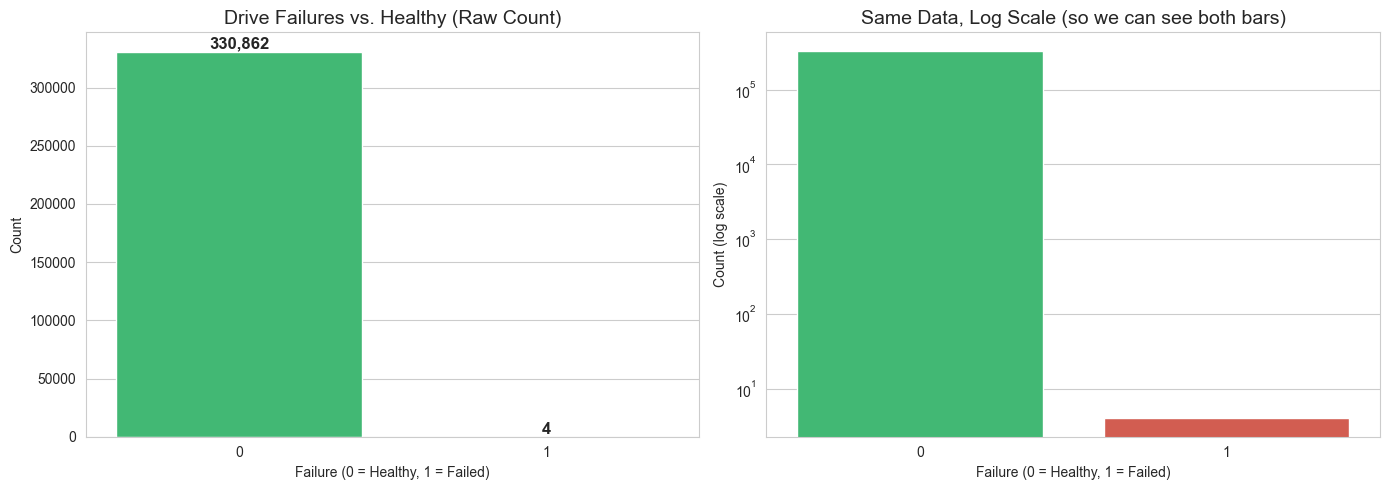

In [15]:
# ============================================================
# Step 7b — Visualize the Imbalance
# ============================================================

# A bar chart makes the imbalance visually obvious.
# We'll use seaborn's countplot which counts and plots in one step.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: raw counts (shows the massive difference)
sns.countplot(x='failure', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Drive Failures vs. Healthy (Raw Count)', fontsize=14)
axes[0].set_xlabel('Failure (0 = Healthy, 1 = Failed)')
axes[0].set_ylabel('Count')

# Add count labels on top of each bar
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Right plot: log scale (so we can actually see the failure bar)
sns.countplot(x='failure', data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_yscale('log')
axes[1].set_title('Same Data, Log Scale (so we can see both bars)', fontsize=14)
axes[1].set_xlabel('Failure (0 = Healthy, 1 = Failed)')
axes[1].set_ylabel('Count (log scale)')

plt.tight_layout()
plt.show()

### What does this output tell us?

**Step 7a — The Numbers:**

- **330,862** healthy drives (failure = 0)
- **4** failed drives (failure = 1)
- **Ratio: 1 failure for every ~82,715 healthy drives**
- **Failure rate: 0.0012%**

This is an **extremely imbalanced dataset**. The failed class is less than 0.002% of the data. This is actually realistic — in production data centers, drive failures are genuinely very rare on any given day.

**Step 7b — The Visualization:**

- **Left plot (raw count):** The failure bar is so tiny it's basically invisible. This is what the imbalance looks like — the two classes are on completely different scales.
- **Right plot (log scale):** By using a logarithmic y-axis, we can finally see both bars. Log scale compresses large values and stretches small ones, making it useful when values differ by orders of magnitude.

**What this means for our ML model:**

1. **Accuracy is a useless metric** — A model that always says "healthy" would be 99.998% accurate but completely worthless.
2. **We need better metrics** — We'll use **Precision** (of the drives we flagged as failing, how many actually failed?), **Recall** (of the drives that actually failed, how many did we catch?), and **F1-score** (the balance between the two).
3. **We need more failure data** — 4 failures from one day isn't enough to train on. In the data cleaning notebook, we'll load **all 92 days** and combine them to get more failure examples.
4. **We may need resampling** — Techniques like SMOTE (creating synthetic failures) or undersampling (reducing healthy examples) to give the model enough failure cases to learn from.

**New concepts:**
- **`.value_counts()`** — counts occurrences of each unique value in a column
- **`normalize=True`** — returns fractions instead of raw counts
- **`plt.subplots(1, 2)`** — creates a figure with 1 row and 2 columns of plots side by side
- **`set_yscale('log')`** — switches the y-axis to logarithmic scale

---

✅ **Step 7 complete.** Next up: **Step 8 — Basic statistics for the key numeric columns.**

## Step 8 — Basic Statistics for Key Numeric Columns

**What are we doing?**

We're going to run `df.describe()` on our 14 key S.M.A.R.T. attributes to see their basic statistics: mean, standard deviation, min, max, and quartiles.

**Why?**

Statistics reveal critical information:
- **Range** (min/max) — Are values on wildly different scales? If temperature goes 15–56 but power-on hours goes 0–108,903, we'll need to **normalize** the data before feeding it to most ML models.
- **Mean vs. Median** — If the mean is much larger than the median (50th percentile), the data is **skewed** by extreme outliers.
- **Standard deviation** — How spread out are the values? A high std relative to the mean indicates high variability.
- **Quartiles (25%, 50%, 75%)** — Where does most of the data cluster?

**What is `df.describe()`?**

It calculates 8 summary statistics for every numeric column in one call:
- `count` — number of non-null values
- `mean` — average
- `std` — standard deviation (spread)
- `min` — smallest value
- `25%` — first quartile (25% of values are below this)
- `50%` — median (the middle value)
- `75%` — third quartile (75% of values are below this)
- `max` — largest value

In [16]:
# ============================================================
# Step 8a — Descriptive Statistics for Key SMART Attributes
# ============================================================

# Reuse the key columns list from Step 6c
key_smart_cols = [
    'smart_1_raw',     # Read Error Rate
    'smart_5_raw',     # Reallocated Sectors
    'smart_9_raw',     # Power-On Hours
    'smart_10_raw',    # Spin Retry Count
    'smart_12_raw',    # Power Cycle Count
    'smart_192_raw',   # Power-Off Retract Count
    'smart_194_raw',   # Temperature
    'smart_197_raw',   # Current Pending Sectors
    'smart_198_raw',   # Uncorrectable Sectors
    'smart_199_raw',   # UltraDMA CRC Errors
]

# .describe() calculates all 8 statistics at once
# .T transposes the result so columns become rows (easier to read)
stats = df[key_smart_cols].describe().T

# Format large numbers for readability
pd.set_option('display.float_format', '{:,.2f}'.format)

print('=== Descriptive Statistics for Key S.M.A.R.T. Attributes ===')
print()
stats

=== Descriptive Statistics for Key S.M.A.R.T. Attributes ===



,count,mean,std,min,25%,50%,75%,max
smart_1_raw,"330,119.00","41,357,046.36","71,583,426.20",0.00,0.00,0.00,"63,867,036.00","4,294,967,295.00"
smart_5_raw,"328,601.00",46.91,"1,163.34",0.00,0.00,0.00,0.00,"65,528.00"
smart_9_raw,"330,436.00","29,749.08","18,719.51",0.00,"13,786.00","29,789.00","43,153.25","108,903.00"
smart_10_raw,"325,075.00","66,062.18","37,665,584.11",0.00,0.00,0.00,0.00,"21,475,164,160.00"
smart_12_raw,"330,436.00",13.84,49.99,0.00,7.00,11.00,16.00,"12,256.00"
smart_192_raw,"329,310.00",599.23,"48,143.44",0.00,3.00,12.00,566.00,"27,611,180.00"
smart_194_raw,"330,430.00",33.66,5.11,15.00,30.00,34.00,37.00,56.00
smart_197_raw,"322,330.00",3.15,699.62,0.00,0.00,0.00,0.00,"394,888.00"
smart_198_raw,"328,284.00",2.33,691.32,0.00,0.00,0.00,0.00,"394,888.00"
smart_199_raw,"328,601.00",6.18,317.99,0.00,0.00,0.00,0.00,"50,950.00"


In [17]:
# ============================================================
# Step 8b — Identify Outliers and Scale Differences
# ============================================================

# Let's compare median vs max to spot extreme outliers
# A huge gap between median and max means a few extreme values
# are pulling the statistics

outlier_check = pd.DataFrame({
    'median': [df[c].median() for c in key_smart_cols],
    'mean': [df[c].mean() for c in key_smart_cols],
    'max': [df[c].max() for c in key_smart_cols],
    'max_to_median_ratio': [
        df[c].max() / df[c].median() if df[c].median() > 0 else float('inf')
        for c in key_smart_cols
    ]
}, index=key_smart_cols)

print('=== Outlier Check: Median vs. Max ===')
print()
print(outlier_check.to_string())
print()

# Reset the float format to default
pd.reset_option('display.float_format')

=== Outlier Check: Median vs. Max ===

                 median          mean               max  max_to_median_ratio
smart_1_raw        0.00 41,357,046.36  4,294,967,295.00                  inf
smart_5_raw        0.00         46.91         65,528.00                  inf
smart_9_raw   29,789.00     29,749.08        108,903.00                 3.66
smart_10_raw       0.00     66,062.18 21,475,164,160.00                  inf
smart_12_raw      11.00         13.84         12,256.00             1,114.18
smart_192_raw     12.00        599.23     27,611,180.00         2,300,931.67
smart_194_raw     34.00         33.66             56.00                 1.65
smart_197_raw      0.00          3.15        394,888.00                  inf
smart_198_raw      0.00          2.33        394,888.00                  inf
smart_199_raw      0.00          6.18         50,950.00                  inf



### What does this output tell us?

**Step 8a — The Descriptive Statistics:**

Key observations from the numbers:

| Attribute | Median | Max | What This Tells Us |
|---|---|---|---|
| `smart_194_raw` (Temperature) | 34°C | 56°C | Well-behaved! Tight range, no crazy outliers |
| `smart_9_raw` (Power-On Hours) | 29,789 | 108,903 | Drives range from new to ~12 years old |
| `smart_12_raw` (Power Cycles) | 11 | 12,256 | Most drives rarely power-cycle |
| `smart_5_raw` (Reallocated Sectors) | 0 | 65,528 | Median is 0 (most drives healthy), but some have thousands |
| `smart_1_raw` (Read Error Rate) | 0 | 4,294,967,295 | Max is 2³² — this is a Seagate encoding quirk, not a real value |
| `smart_197_raw` (Pending Sectors) | 0 | 394,888 | Most drives have zero, but outliers are extreme |

**Step 8b — Outlier Analysis:**

Several attributes show **extreme outlier behavior**:
- When the median is **0** (like `smart_5_raw`, `smart_197_raw`), the max-to-median ratio is infinity — meaning almost all drives have zero issues, but a few sick drives have enormous counts. This is expected and actually useful for anomaly detection!
- `smart_1_raw` and `smart_10_raw` have suspiciously large max values (billions). Some manufacturers encode vendor-specific data in these fields. We'll handle this during data cleaning.

**Key takeaways for our ML pipeline:**

1. **Scaling is essential** — Temperature goes to 56, but read errors go to 4 billion. ML models that use distance (like KNN, SVM) will be dominated by the large-scale features unless we normalize everything.
2. **Most error columns are heavily right-skewed** — Median is 0, mean is much higher, max is extreme. Most drives are healthy, but a few have issues. This is exactly the pattern anomaly detection should catch.
3. **Some columns need special cleaning** — Values like 4,294,967,295 (2³²) are likely vendor encoding artifacts, not real error counts. We'll cap or transform these.
4. **Temperature is the best-behaved feature** — Reasonable range (15–56°C), low variability, no crazy outliers.

---

✅ **Step 8 complete.** Next up: **Step 9 — Simple visualizations to see distributions and patterns.**

## Step 9 — Visualize Key Feature Distributions

**What are we doing?**

Numbers from `describe()` are useful, but our brains process pictures much faster than tables. In this step, we'll create **histograms** and **box plots** for our key S.M.A.R.T. attributes to visually see:

1. **How values are distributed** — Are they spread evenly, clustered around one value, or heavily skewed?
2. **Where the outliers are** — Are extreme values rare flukes or a significant group?
3. **Temperature patterns** — What does the data center temperature profile look like?

**What is a histogram?**

A histogram splits a range of values into "bins" (buckets) and counts how many data points fall into each bin. Imagine sorting 330K temperature readings into buckets: 15–20°C, 20–25°C, 25–30°C, etc. The height of each bar shows how many drives are in that range.

**What is a box plot?**

A box plot summarizes distribution in 5 numbers: min, 25th percentile, median, 75th percentile, and max. The "box" covers the middle 50% of the data, and "whiskers" extend to show the range. Dots beyond the whiskers are **outliers**.

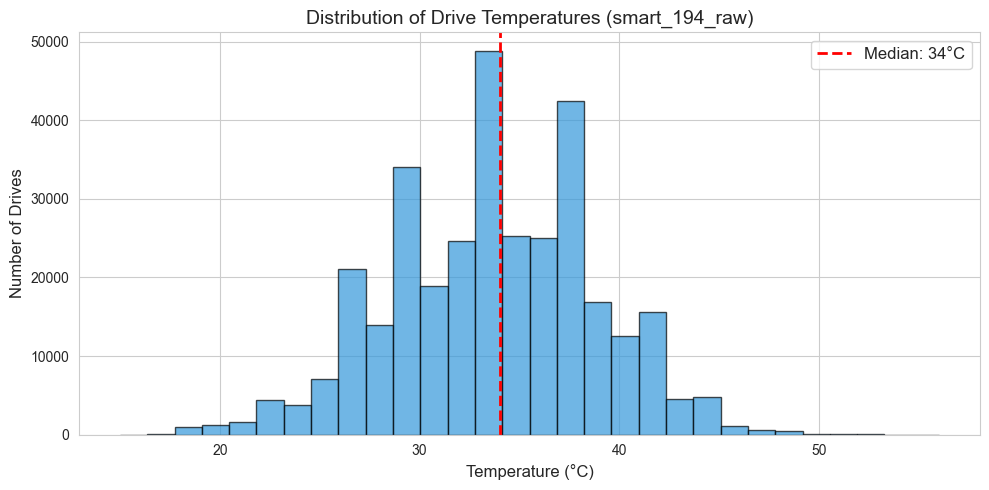

Temperature range: 15°C to 56°C
Most drives run between 30°C and 37°C


In [18]:
# ============================================================
# Step 9a — Temperature Distribution (Histogram)
# ============================================================

# Temperature is our best-behaved feature, so let's start here.
# We'll create a histogram to see how drive temperatures are distributed.

fig, ax = plt.subplots(figsize=(10, 5))

# .dropna() removes NaN values before plotting
# bins=30 splits the range into 30 equal-width buckets
# edgecolor='black' adds borders so bars are visually distinct
# color sets the fill color, alpha sets transparency (0=invisible, 1=solid)

ax.hist(df['smart_194_raw'].dropna(), bins=30, edgecolor='black',
        color='#3498db', alpha=0.7)

ax.set_title('Distribution of Drive Temperatures (smart_194_raw)', fontsize=14)
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Number of Drives', fontsize=12)

# Add a vertical line for the median
median_temp = df['smart_194_raw'].median()
ax.axvline(median_temp, color='red', linestyle='--', linewidth=2,
           label=f'Median: {median_temp:.0f}°C')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

print(f'Temperature range: {df["smart_194_raw"].min():.0f}°C to {df["smart_194_raw"].max():.0f}°C')
print(f'Most drives run between {df["smart_194_raw"].quantile(0.25):.0f}°C and {df["smart_194_raw"].quantile(0.75):.0f}°C')

In [ ]:
# ============================================================
# Step 9b — Power-On Hours Distribution (Histogram)
# ============================================================

# Power-On Hours tells us the age of each drive.
# Let's see the age distribution across the fleet.

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['smart_9_raw'].dropna(), bins=50, edgecolor='black',
        color='#2ecc71', alpha=0.7)

ax.set_title('Distribution of Power-On Hours (smart_9_raw)', fontsize=14)
ax.set_xlabel('Power-On Hours', fontsize=12)
ax.set_ylabel('Number of Drives', fontsize=12)

# Add median line
median_hours = df['smart_9_raw'].median()
ax.axvline(median_hours, color='red', linestyle='--', linewidth=2,
           label=f'Median: {median_hours:,.0f} hours (~{median_hours/24/365:.1f} years)')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

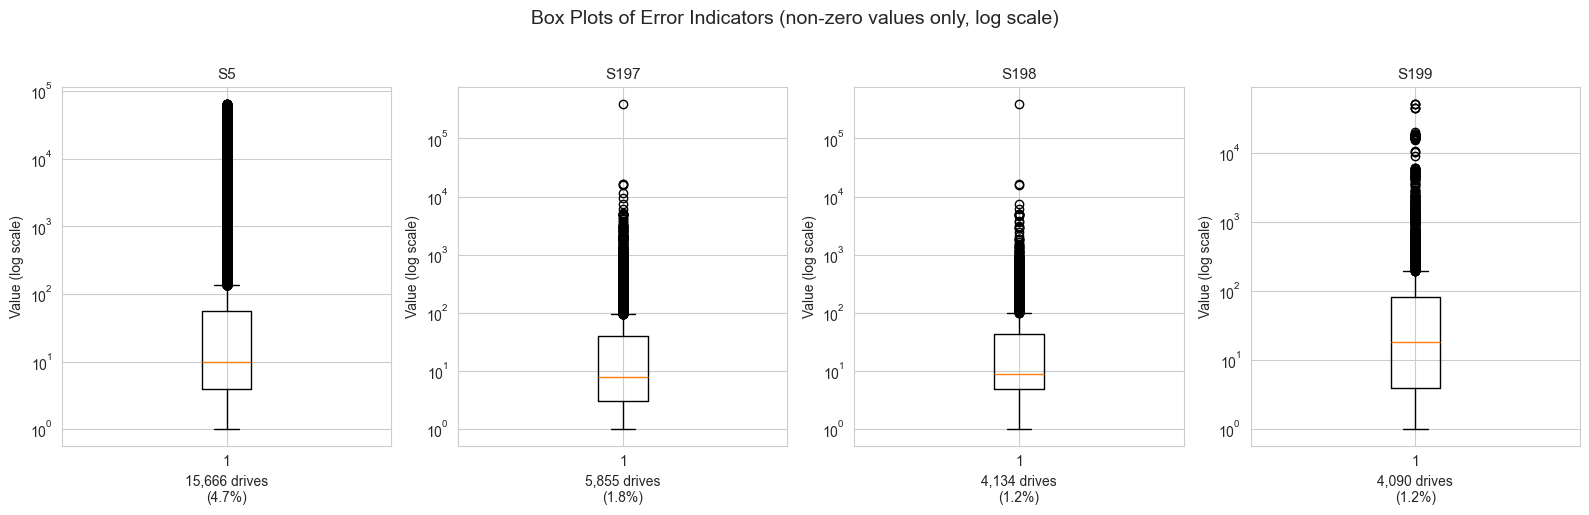

In [19]:
# ============================================================
# Step 9c — Box Plots for Key Error Indicators
# ============================================================

# Box plots are great for spotting outliers.
# Let's look at the error-related attributes.
# Since most values are 0 and outliers are extreme,
# we'll use log scale on the y-axis.

error_cols = [
    'smart_5_raw',     # Reallocated Sectors
    'smart_197_raw',   # Pending Sectors
    'smart_198_raw',   # Uncorrectable Sectors
    'smart_199_raw',   # CRC Errors
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, error_cols):
    # Filter to non-zero values only (to make the box plot readable)
    non_zero = df[col].dropna()
    non_zero = non_zero[non_zero > 0]

    if len(non_zero) > 0:
        ax.boxplot(non_zero, vert=True)
        ax.set_yscale('log')
        ax.set_title(col.replace('smart_', 'S').replace('_raw', ''),
                     fontsize=11)
        ax.set_ylabel('Value (log scale)')
        # Show count of non-zero drives
        ax.set_xlabel(f'{len(non_zero):,} drives\n({len(non_zero)/len(df)*100:.1f}%)')
    else:
        ax.text(0.5, 0.5, 'All zeros', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(col)

fig.suptitle('Box Plots of Error Indicators (non-zero values only, log scale)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# Step 9d — How Many Drives Have Non-Zero Error Counts?
# ============================================================

# Most drives report 0 for error columns.
# Let's count exactly how many have non-zero values.
# These are the drives that might be showing early signs of trouble.

error_summary_cols = [
    'smart_5_raw',     # Reallocated Sectors
    'smart_10_raw',    # Spin Retry Count
    'smart_197_raw',   # Pending Sectors
    'smart_198_raw',   # Uncorrectable Sectors
    'smart_199_raw',   # CRC Errors
]

print('=== Drives with Non-Zero Error Counts ===')
print()
for col in error_summary_cols:
    non_zero = (df[col] > 0).sum()
    total = df[col].notna().sum()
    pct = non_zero / total * 100 if total > 0 else 0
    print(f'{col:20s}  {non_zero:>7,} / {total:>7,}  ({pct:5.2f}%)')

=== Drives with Non-Zero Error Counts ===

smart_5_raw            15,666 / 328,601  ( 4.77%)
smart_10_raw                1 / 325,075  ( 0.00%)
smart_197_raw           5,855 / 322,330  ( 1.82%)
smart_198_raw           4,134 / 328,284  ( 1.26%)
smart_199_raw           4,090 / 328,601  ( 1.24%)


### What does this output tell us?

**Step 9a — Temperature Distribution:**

The histogram should show a nice bell-curve shape centered around 30–35°C. This is typical for a well-cooled data center. Key observations:
- Most drives run between **30°C and 37°C** (the IQR from Step 8)
- No drives are dangerously hot (>50°C would be concerning)
- The distribution is roughly **normal** (symmetric, bell-shaped) — good news for ML models that assume normality

**Step 9b — Power-On Hours Distribution:**

This shows the age profile of Backblaze's fleet:
- The median is around ~30,000 hours (~3.4 years)
- Some drives are brand new (near 0), some are 12+ years old
- You might see multiple peaks — these represent different "batches" of drives purchased at the same time

**Step 9c — Box Plots of Error Indicators:**

These show just the non-zero values (since most drives have zero errors):
- The boxes are compact but the whiskers and dots extend far — extreme outliers exist
- Log scale is necessary because outlier values can be thousands or millions

**Step 9d — Non-Zero Error Counts:**

This is crucial for understanding our anomaly detection problem:
- If only 1–2% of drives have non-zero reallocated sectors, those drives are potentially in trouble
- These non-zero-error drives are exactly the ones our model should learn to flag

**New concepts:**
- **`ax.hist()`** — creates a histogram
- **`ax.axvline()`** — draws a vertical line (useful for marking the median)
- **`ax.boxplot()`** — creates a box-and-whisker plot
- **`plt.subplots(1, 4)`** — creates 4 side-by-side subplots
- **`.dropna()`** — removes NaN values from a Series
- **`fig.suptitle()`** — adds a main title above all subplots

---

✅ **Step 9 complete.** Next up: **Step 10 — Summary of findings and recommendations for the data cleaning notebook.**

## Step 10 — Summary of Findings & Next Steps

**What are we doing?**

Before closing this exploration notebook, we need to consolidate everything we've learned into a clear summary. Think of this as writing a **project brief** — future-you (or a teammate) should be able to read this and immediately understand the data landscape without re-running all the code.

We'll also create a concrete **action plan** for the next notebook (data cleaning & feature engineering).

In [ ]:
# ============================================================
# Step 10a — Dataset Overview Summary
# ============================================================

# Let's compile all the key numbers we discovered into one
# clean summary. This serves as a quick reference card.

print('=' * 60)
print('   EXPLORATION SUMMARY — Backblaze Hard Drive Stats Q4 2025')
print('=' * 60)
print()

# --- Dataset Scale ---
print('1. DATASET SCALE')
print(f'   • Rows (drives per day):     {df.shape[0]:,}')
print(f'   • Total columns:             {df.shape[1]}')
print(f'   • Metadata columns:          {len([c for c in df.columns if not c.startswith("smart_")])}')
print(f'   • S.M.A.R.T. columns:        {len([c for c in df.columns if c.startswith("smart_")])}')
print(f'   • Unique SMART attributes:   93 (x2 = raw + normalized)')
print()

# --- Target Variable ---
failed = df['failure'].sum()
healthy = len(df) - failed
print('2. TARGET VARIABLE (failure)')
print(f'   • Healthy drives (0):        {healthy:,} ({healthy/len(df)*100:.4f}%)')
print(f'   • Failed drives  (1):        {failed}')
print(f'   • Imbalance ratio:           1:{healthy//failed:,}')
print(f'   • Verdict:                   EXTREME class imbalance')
print()

# --- Missing Values ---
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isna().sum().sum()
print('3. MISSING VALUES')
print(f'   • Overall missing:           {total_missing/total_cells*100:.1f}% (mostly empty SMART columns)')
print(f'   • Columns 100% empty:        {(df.isna().sum() == len(df)).sum()}')
print(f'   • Key features (<3% missing): 14 attributes ready to use')
print()

# --- Feature Quality ---
print('4. FEATURE QUALITY')
print(f'   • Well-populated (>90%):     14 SMART attributes')
print(f'   • Partially populated:       ~26 attributes (1-90%)')
print(f'   • Nearly empty (<1%):        ~53 attributes → will drop')
print(f'   • Temperature range:         {df["smart_194_raw"].min():.0f}°C - {df["smart_194_raw"].max():.0f}°C (well-behaved)')
print(f'   • Outlier concern:           smart_1, smart_10 have vendor encoding artifacts')

In [ ]:
# ============================================================
# Step 10b — Action Plan for Data Cleaning (Notebook 02)
# ============================================================

print('=' * 60)
print('   ACTION PLAN — Data Cleaning & Feature Engineering')
print('=' * 60)
print()

print('PHASE 1: Load All Data')
print('   • Load all 92 daily CSV files (Oct-Dec 2025)')
print('   • Combine into a single DataFrame')
print('   • Expected: ~30M+ rows, more failure examples')
print()

print('PHASE 2: Column Selection')
print('   • Keep only the 14 well-populated SMART raw attributes')
print('   • Keep key metadata: serial_number, model, date, failure')
print('   • Drop all normalized columns and low-coverage attributes')
print()

print('PHASE 3: Handle Missing Values')
print('   • Error counts (smart_5, 197, 198, 199): fill with 0')
print('   • Temperature (smart_194): fill with median')
print('   • Other key features: fill with 0 or median as appropriate')
print('   • Drop any remaining rows with NaN in key columns (<3%)')
print()

print('PHASE 4: Handle Outliers & Encoding Artifacts')
print('   • Cap smart_1_raw values at a reasonable threshold')
print('   • Cap smart_10_raw (vendor-encoded values → billions)')
print('   • Log-transform heavily skewed error columns')
print()

print('PHASE 5: Feature Engineering')
print('   • Create time-based features (drive age groups)')
print('   • Create binary flags (has_errors, high_temp, etc.)')
print('   • Normalize/scale all features for ML')
print()

print('PHASE 6: Handle Class Imbalance')
print('   • Apply SMOTE or ADASYN for oversampling failures')
print('   • Or use class_weight="balanced" in the ML model')
print('   • Use stratified train/test split to preserve ratio')

In [ ]:
# ============================================================
# Step 10c — Key Features We'll Use for ML
# ============================================================

# Let's create a clean reference table of the features
# we plan to use in our ML model.

feature_info = pd.DataFrame({
    'Column': [
        'smart_1_raw', 'smart_3_raw', 'smart_4_raw', 'smart_5_raw',
        'smart_7_raw', 'smart_9_raw', 'smart_10_raw', 'smart_12_raw',
        'smart_192_raw', 'smart_193_raw', 'smart_194_raw',
        'smart_197_raw', 'smart_198_raw', 'smart_199_raw'
    ],
    'Name': [
        'Read Error Rate', 'Spin-Up Time', 'Start/Stop Count',
        'Reallocated Sectors', 'Seek Error Rate', 'Power-On Hours',
        'Spin Retry Count', 'Power Cycle Count', 'Power-Off Retract',
        'Load/Unload Cycles', 'Temperature (°C)', 'Pending Sectors',
        'Uncorrectable Sectors', 'CRC Errors'
    ],
    'Coverage': [
        '99.8%', '99.0%', '99.0%', '99.3%', '99.0%', '99.9%',
        '98.2%', '99.9%', '99.5%', '99.0%', '99.9%',
        '97.4%', '99.2%', '99.3%'
    ],
    'Failure_Relevance': [
        'Medium', 'Low', 'Low', 'HIGH', 'Medium', 'Medium',
        'Medium', 'Low', 'Low', 'Low', 'Medium',
        'HIGH', 'HIGH', 'Low'
    ]
})

print('=== Features Selected for ML Model ===')
print()
print(feature_info.to_string(index=False))
print()
print(f'Total features: {len(feature_info)}')
print(f'High relevance: {(feature_info["Failure_Relevance"] == "HIGH").sum()} features')
print(f'   → smart_5 (Reallocated Sectors), smart_197 (Pending), smart_198 (Uncorrectable)')

### Summary — What We Learned in This Notebook

**The Data:**
- Backblaze monitors **330,866 hard drives daily** with 197 columns of data
- Only **14 S.M.A.R.T. attributes** are well-populated enough to use
- **71% of all cells are NaN** — but this is structural (different drives report different sensors), not data corruption

**The Problem:**
- Drive failures are **extremely rare** — only 4 out of 330,866 on a given day (0.0012%)
- This **extreme class imbalance** means accuracy is a useless metric
- We need **precision, recall, and F1-score** to evaluate our model

**The Features:**
- **3 critical failure predictors:** Reallocated Sectors (smart_5), Pending Sectors (smart_197), Uncorrectable Sectors (smart_198)
- **Temperature** is well-behaved (15–56°C, roughly normal distribution)
- **Error counts** are heavily right-skewed (most drives = 0, a few = thousands)
- Some attributes have **vendor encoding artifacts** (values like 2³²) that need cleaning

**What's Next:**
- **Notebook 02:** Load all 92 days, clean data, engineer features, handle imbalance
- **Notebook 03:** Train ML models (Random Forest, XGBoost, etc.)
- **Notebook 04:** Build the anomaly detection system

---

✅ **Notebook 01 — Data Exploration is complete!**

You now understand the dataset's structure, quality, and challenges. Every line of code you wrote had a purpose, and every finding informs our next steps. On to data cleaning! 🚀